# 🏡 Proyecto de Regresión: Predicción de Precios de Viviendas en California

En este cuaderno, aplicaremos el flujo de trabajo completo de un proyecto de Machine Learning para resolver un problema de **regresión**: predecir el valor mediano de las viviendas en distritos de California.

Utilizaremos el conjunto de datos **California Housing**, que es un dataset clásico disponible en Scikit-learn.

## 🎯 Objetivos

1.  **Cargar y Explorar los Datos (EDA)**: Entender la estructura, características y distribución de los datos.
2.  **Visualizar los Datos**: Crear gráficos para descubrir patrones y correlaciones.
3.  **Preparar los Datos**: Dividir en conjuntos de entrenamiento/prueba y escalar las características.
4.  **Entrenar Múltiples Modelos**: Implementar y entrenar modelos de regresión como `LinearRegression`, `Ridge`, `Lasso` y `RandomForestRegressor`.
5.  **Evaluar los Modelos**: Medir el rendimiento de cada modelo utilizando métricas como MAE, MSE y R².
6.  **Analizar Resultados**: Comparar los modelos y extraer conclusiones.

## 📚 Paso 1: Importar las Librerías Necesarias

Primero, importamos todas las herramientas que necesitaremos para nuestro análisis.

In [1]:
# Manipulación y análisis de datos
import numpy as np
import pandas as pd

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos y preprocesamiento
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos de Regresión
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración para visualizaciones
plt.style.use('default')
sns.set(style='whitegrid')
%matplotlib inline 

print('✅ Librerías importadas correctamente.')

✅ Librerías importadas correctamente.


## 📊 Paso 2: Cargar y Explorar los Datos (EDA)

Cargamos el dataset `California Housing` desde Scikit-learn. Este dataset ya viene limpio y listo para usar.

In [2]:
# Cargar el dataset
california = fetch_california_housing()

# El objeto 'california' es un diccionario. Exploremos sus claves.
print('Claves del dataset:', california.keys())

# Descripción del dataset
print('\nDescripción del dataset:')
print(california.DESCR)

Claves del dataset: dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

Descripción del dataset:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expr

### Convertir a DataFrame de Pandas

Para facilitar la manipulación y visualización, convertimos los datos a un DataFrame de Pandas.

In [3]:
# Crear el DataFrame
df = pd.DataFrame(california.data, columns=california.feature_names)

# Añadir la variable objetivo (target)
df['MedHouseVal'] = california.target

print('Primeras 5 filas del DataFrame:')
display(df.head())

Primeras 5 filas del DataFrame:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Información General y Estadísticas

Veamos un resumen de la estructura y estadísticas descriptivas.

In [4]:
# Información general (tipos de datos, valores no nulos)
print('Información del DataFrame:')
df.info()

# Estadísticas descriptivas
print('\nEstadísticas Descriptivas:')
display(df.describe())

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Estadísticas Descriptivas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 📈 Paso 3: Visualización de Datos

La visualización es clave para entender las relaciones entre las variables.

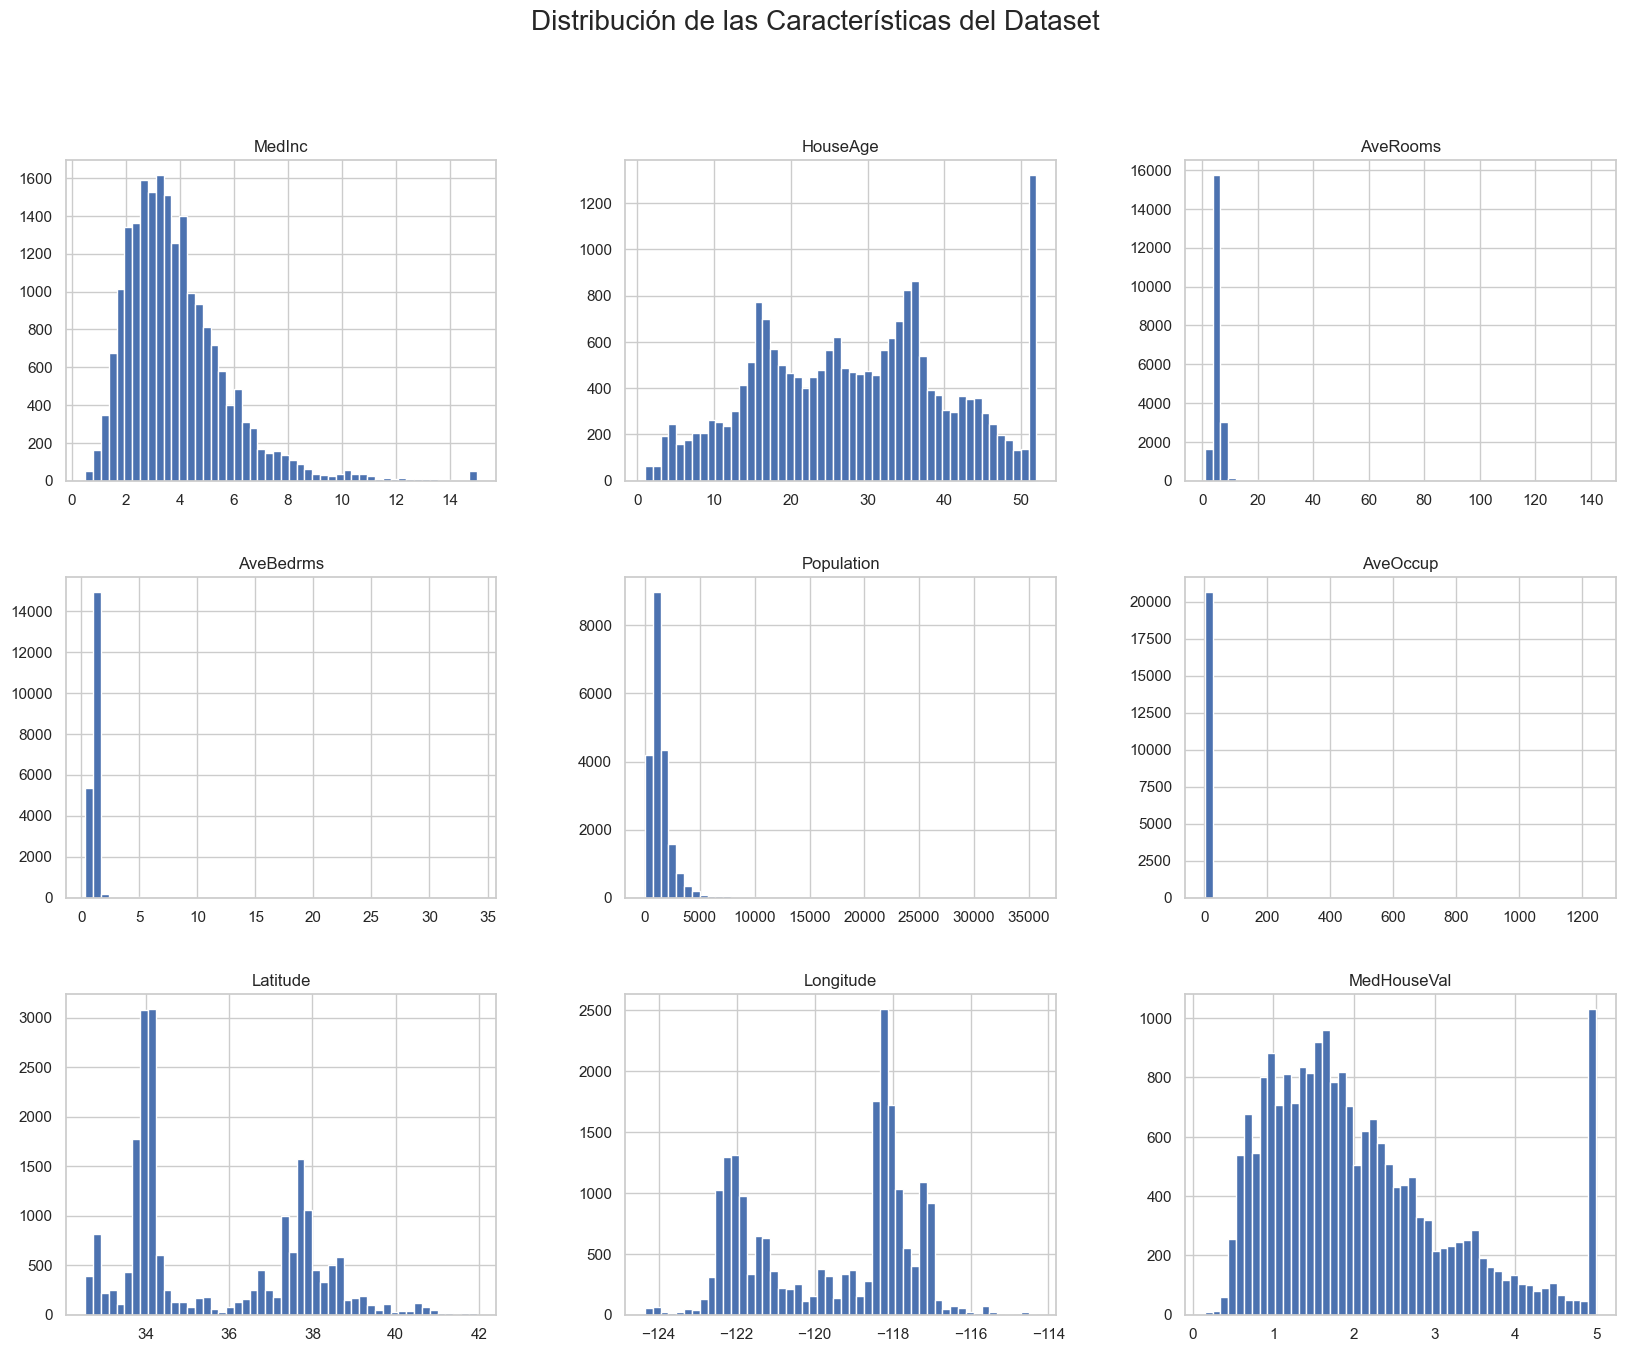

In [5]:
# Histogramas de todas las características para ver su distribución
df.hist(bins=50, figsize=(20, 15))
plt.suptitle('Distribución de las Características del Dataset', size=20)
plt.show()

### Visualización Geográfica de Precios

Un scatter plot de latitud y longitud nos dará una idea de cómo se distribuyen los precios geográficamente.

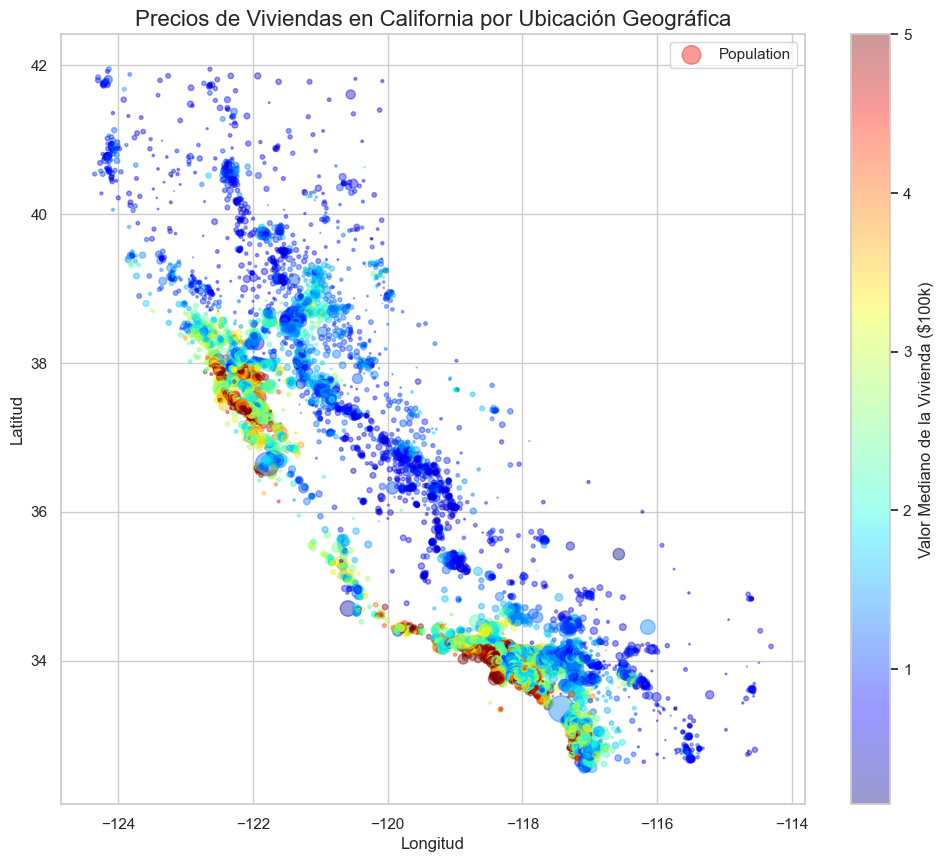

In [6]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(df['Longitude'], df['Latitude'], alpha=0.4,
                    s=df['Population']/100, label='Population',
                    c=df['MedHouseVal'], cmap=plt.get_cmap('jet'))
plt.colorbar(scatter).set_label('Valor Mediano de la Vivienda ($100k)')
plt.title('Precios de Viviendas en California por Ubicación Geográfica', fontsize=16)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend()
plt.show()

### Matriz de Correlación

Veamos qué características están más correlacionadas con el precio de la vivienda.

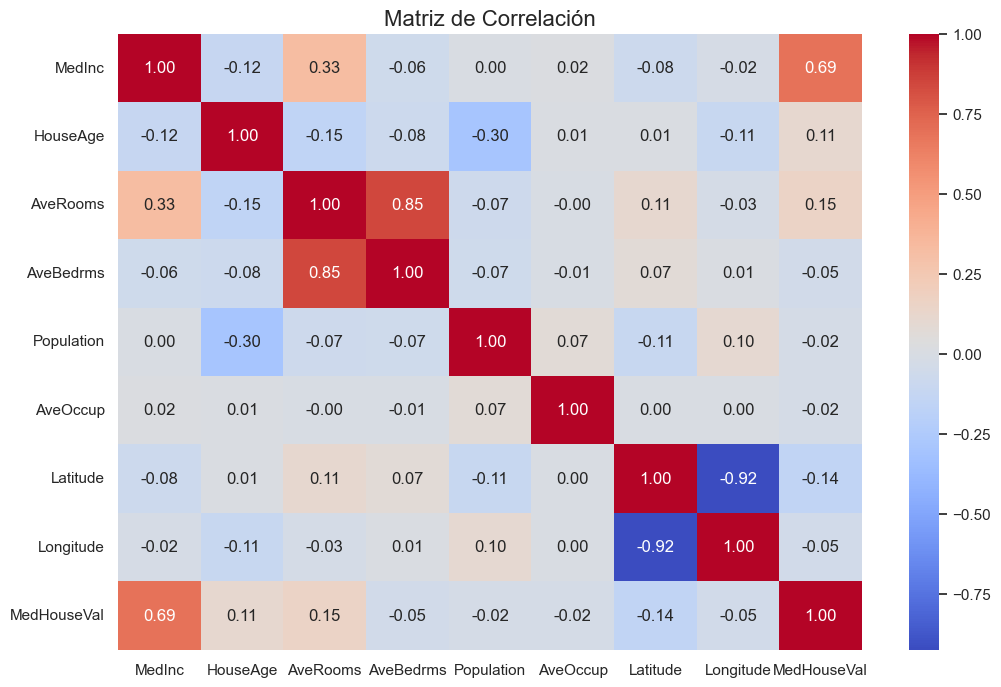

In [7]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación', fontsize=16)
plt.show()

**Observación Clave**: La característica `MedInc` (ingreso mediano) es la que tiene la correlación positiva más alta con `MedHouseVal` (nuestro objetivo).

## ⚙️ Paso 4: Preparación de Datos

Ahora, preparamos los datos para el entrenamiento del modelo.

In [8]:
# 1. Separar características (X) y objetivo (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# 2. Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Tamaño del conjunto de prueba: {X_test.shape[0]} muestras')

Tamaño del conjunto de entrenamiento: 16512 muestras
Tamaño del conjunto de prueba: 4128 muestras


### Escalado de Características

Muchos modelos de Machine Learning funcionan mejor cuando las características numéricas están en una escala similar. Usaremos `StandardScaler` para estandarizar los datos (media 0, desviación estándar 1).

In [9]:
# Crear el escalador
scaler = StandardScaler()

# Ajustar y transformar los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformar los datos de prueba (usando el mismo escalador ajustado en train)
X_test_scaled = scaler.transform(X_test)

print('Datos escalados correctamente.')

Datos escalados correctamente.


## 🤖 Paso 5: Entrenamiento de Modelos

Entrenaremos varios modelos de regresión para comparar su rendimiento.

In [10]:
# Diccionario para almacenar los modelos
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Entrenar cada modelo
for name, model in models.items():
    print(f'Entrenando {name}...')
    model.fit(X_train_scaled, y_train)

print('\n✅ Todos los modelos han sido entrenados.')

Entrenando Linear Regression...
Entrenando Ridge Regression...
Entrenando Lasso Regression...
Entrenando Random Forest...

✅ Todos los modelos han sido entrenados.

✅ Todos los modelos han sido entrenados.


## ⚖️ Paso 6: Evaluación de Modelos

Ahora, evaluamos el rendimiento de cada modelo en el conjunto de prueba, que son datos que nunca han visto.

In [11]:
# DataFrame para almacenar los resultados
results = pd.DataFrame(columns=['MAE', 'MSE', 'R²'])

for name, model in models.items():
    # Realizar predicciones
    y_pred = model.predict(X_test_scaled)
    
    # Calcular métricas
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Almacenar resultados
    results.loc[name] = [mae, mse, r2]

print('Resultados de la evaluación de modelos:')
display(results.sort_values(by='R²', ascending=False))

Resultados de la evaluación de modelos:


,MAE,MSE,R²
Random Forest,0.327425,0.255170,0.805275
Ridge Regression,0.533193,0.555855,0.575816
Linear Regression,0.533200,0.555892,0.575788
Lasso Regression,0.906069,1.310696,-0.000219


### Interpretación de las Métricas

- **MAE (Mean Absolute Error)**: El error promedio absoluto de las predicciones. Un valor más bajo es mejor. (Ej: 0.33 significa que, en promedio, el modelo se equivoca en $33,000).
- **MSE (Mean Squared Error)**: Similar al MAE pero penaliza más los errores grandes. Un valor más bajo es mejor.
- **R² (Coeficiente de Determinación)**: Indica qué proporción de la varianza en la variable objetivo es predecible a partir de las características. Un valor más cercano a 1 es mejor. (Ej: 0.81 significa que el modelo explica el 81% de la variabilidad de los precios).

## 🌲 Paso 7: Análisis del Mejor Modelo (Random Forest)

El `RandomForestRegressor` ha dado los mejores resultados. Analicemos qué características considera más importantes.

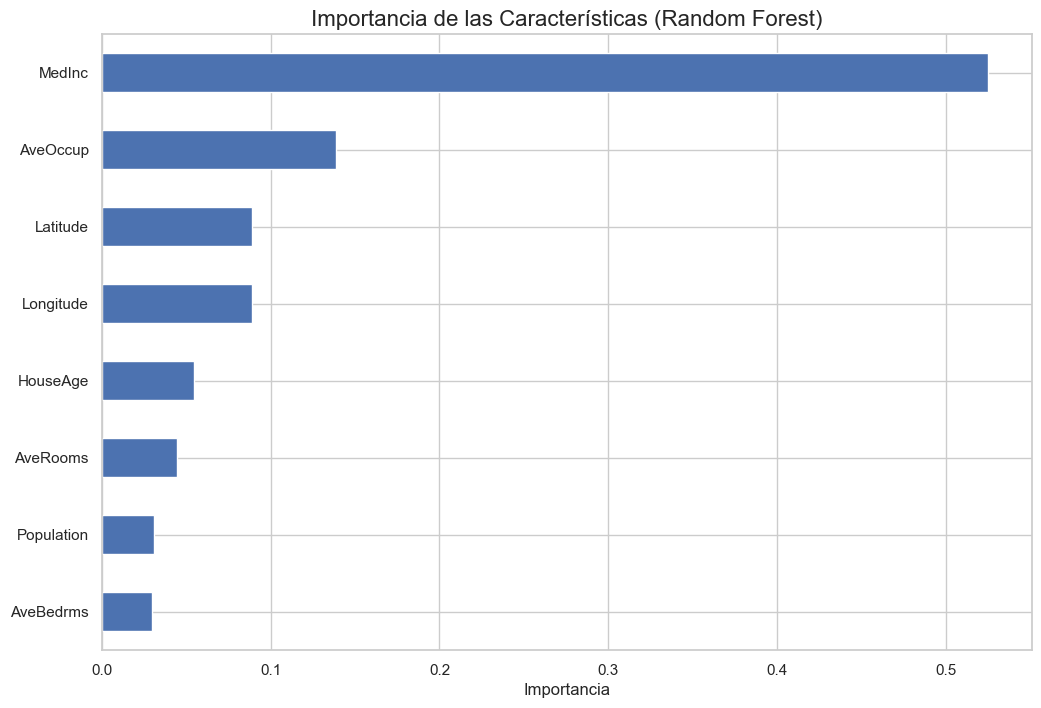

In [12]:
# Obtener el modelo Random Forest
rf_model = models['Random Forest']

# Obtener la importancia de las características
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Visualizar la importancia
plt.figure(figsize=(12, 8))
feature_importances.nlargest(10).sort_values().plot(kind='barh')
plt.title('Importancia de las Características (Random Forest)', fontsize=16)
plt.xlabel('Importancia')
plt.show()

## 🏁 Paso 8: Conclusión

En este proyecto, hemos seguido el flujo de trabajo completo de Machine Learning para predecir los precios de las viviendas en California.

### Hallazgos Clave:

1.  **El modelo `RandomForestRegressor` fue el de mejor rendimiento**, explicando aproximadamente el **81%** de la variabilidad en los precios de las viviendas (R² ≈ 0.81).
2.  Las características más importantes para predecir el precio son, en orden:
    - **Ingreso Mediano (`MedInc`)**: Confirma nuestra observación inicial del EDA.
    - **Ubicación Geográfica (`Longitude`, `Latitude`)**: La localización es un factor crucial en el precio.
    - **Antigüedad de la Vivienda (`HouseAge`)**.
3.  Los modelos de regresión lineal (Lineal, Ridge, Lasso) tuvieron un rendimiento inferior pero similar entre sí, explicando alrededor del 59% de la varianza. Esto sugiere que la relación entre las características y el precio no es puramente lineal.

### Próximos Pasos Posibles:

- **Ajuste de Hiperparámetros**: Usar técnicas como `GridSearchCV` o `RandomizedSearchCV` para encontrar la mejor configuración para el `RandomForestRegressor` y mejorar aún más su rendimiento.
- **Ingeniería de Características (Feature Engineering)**: Crear nuevas características combinando las existentes (ej: `habitaciones_por_persona`) para ver si mejoran el modelo.
- **Probar otros modelos**: Explorar modelos más avanzados como `GradientBoostingRegressor` o `XGBoost`.